In [1]:
import pandas as pd
import numpy as np
from pandas.core.interchange.dataframe_protocol import DataFrame

df = pd.read_csv('data/surveyDataSience.csv', low_memory=False)

print("Number of responses: ", df.shape[0])

Number of responses:  25974


In [2]:
df.dtypes

Time from Start to Finish (seconds)    str
Q1                                     str
Q2                                     str
Q3                                     str
Q4                                     str
                                      ... 
Q38_B_Part_8                           str
Q38_B_Part_9                           str
Q38_B_Part_10                          str
Q38_B_Part_11                          str
Q38_B_OTHER                            str
Length: 369, dtype: object

In [ ]:
print("Number of complete responses: ", df.dropna().shape[0])

Number of complete responses:  1


In [ ]:
# df['Q4'].value_counts() all the answers
def study_year(education: str):
    if education == 'No formal education past high school' or education == 'I prefer not to answer':
        return 0
    if education == "Some college/university study without earning a bachelor’s degree":
        return 1
    if education == "Bachelor’s degree":
        return 3
    if education == "Master’s degree":
        return 5
    if education == "Doctoral degree":
        return 8
    return None

print("Avg for all respondents:", df["Q4"].apply(study_year).mean())
print("Avg for romanian woman:", df[(df["Q3"] == "Romania") & (df["Q2"] == "Woman")]["Q4"].apply(study_year).mean())


Avg for all respondents: 4.322748475062792
Avg for romanian woman: 5.666666666666667


In [6]:
print("Number of romanian woman with complete responses", df[(df["Q3"] == "Romania") & (df["Q2"] == "Woman")].dropna().shape[0])

Number of romanian woman with complete responses 0


In [8]:
ro_wo_py = df[(df["Q3"] == "Romania") & (df["Q2"] == "Woman") & (df["Q7_Part_1"] == "Python")]

print("Number of ro woman that code in Python: ", ro_wo_py.shape[0])
print("Biggest interval for ro woman coding in Python: ", ro_wo_py["Q1"].value_counts().idxmax())

ro_wo_cpp = df[(df["Q3"] == "Romania") & (df["Q2"] == "Woman") & (df["Q7_Part_5"] == "C++")]

print("Number of ro woman that code in Python: ", ro_wo_cpp.shape[0])
print("Biggest interval for ro woman coding in Python: ", ro_wo_cpp["Q1"].value_counts().idxmax())

Number of ro woman that code in Python:  12
Biggest interval for ro woman coding in Python:  35-39
Number of ro woman that code in Python:  4
Biggest interval for ro woman coding in Python:  18-21


In [19]:
for col in df.columns:
    #print("Feature: ", col)
    numeric_values = pd.to_numeric(df[col], errors='coerce')

    if numeric_values.notna().sum():
        print("Feature: ", col)
        print("Numeric values with max: {} and min: {}".format(numeric_values.max(), numeric_values.min()))


Feature:  Time from Start to Finish (seconds)
Numeric values with max: 2488653.0 and min: 120.0
Feature:  Q22
Numeric values with max: 0.0 and min: 0.0


In [ ]:
# df[df['Q6'] == "20+ years"]['Q1'].value_counts() # the oldest person is 60-69 with 302 responses
# how tf is there a person between 18-21 with 20+ years of coding???

years_of_coding_avg_map = {
    "1-3 years": 2,
    "< 1 year": 0.5,
    "3-5 years": 4,
    "5-10 years": 7.5,
    "10-20 years": 15,
    "20+ years": 45,
    "I have never written code": 0
}

df_oldness = df['Q6'].map(years_of_coding_avg_map)

print("Most experience: ", df_oldness.max())
print("Least experience: ", df_oldness.min())
print("Average experience: ", df_oldness.mean())
print("The median: ", df_oldness.median())
print("Variance: ", df_oldness.var()) # this is wierd, how is it 165.15?
print("Standard deviation: ", df_oldness.std())

Most experience:  45.0
Least experience:  0.0
Average experience:  7.7504462791476065
The median:  4.0
Variance:  165.15963020528685
Standard deviation:  12.851444673860088


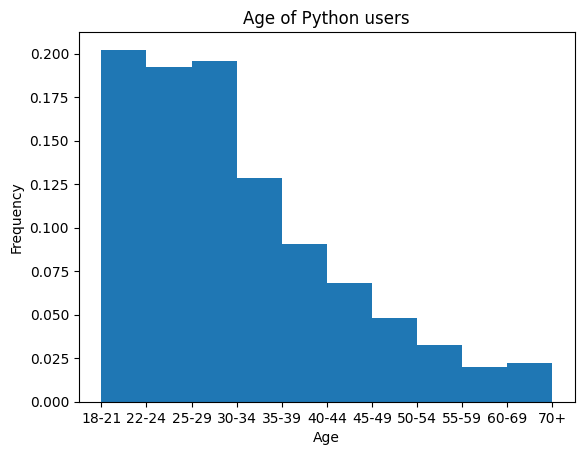

In [64]:
import matplotlib.pyplot as plt

python_users = df[df["Q7_Part_1"] == "Python"]
plt.hist(python_users["Q1"].sort_values(), density=True)
plt.title("Age of Python users")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

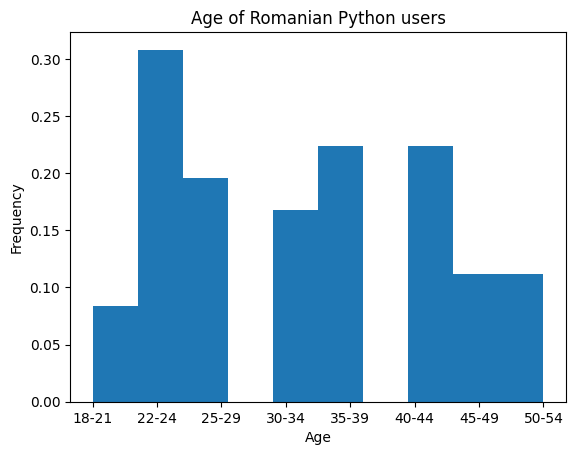

In [65]:
romanian_python_users = df[(df["Q3"] == "Romania") & (df["Q7_Part_1"] == "Python")]
plt.hist(romanian_python_users["Q1"].sort_values(), density=True)
plt.title("Age of Romanian Python users")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

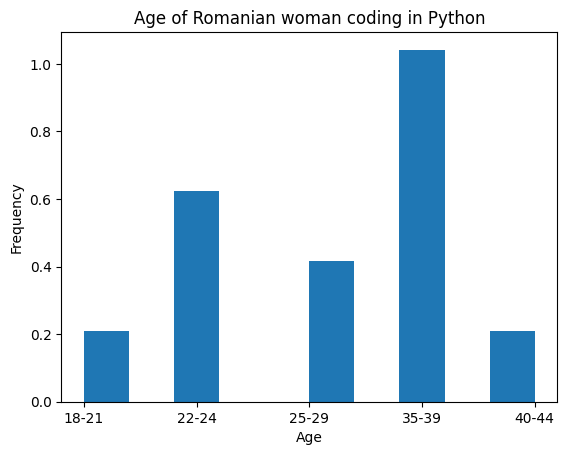

In [69]:
plt.hist(ro_wo_py["Q1"].sort_values(), density=True)
plt.title("Age of Romanian woman coding in Python")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

45.0
Q6
2.0     7874
4.0     4061
7.5     3099
45.0    1860
0.0     1032
Name: count, dtype: int64


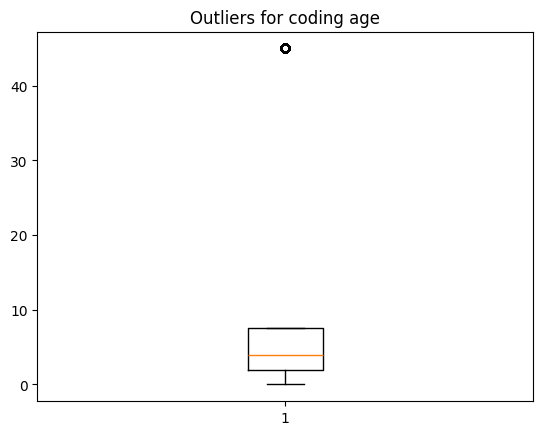

In [77]:
print(df_oldness.dropna().max())
print(df_oldness.value_counts())
plt.boxplot(df_oldness.dropna())
plt.title("Outliers for coding age")
plt.show()